In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import warnings

In [2]:
df = pd.read_csv('data/RainPred.csv')

In [3]:
df.head()

,Date,Location,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
0,2024-01-01,New York,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278,0
1,2024-01-02,New York,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065,0
2,2024-01-03,New York,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739,1
3,2024-01-04,New York,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163,0
4,2024-01-05,New York,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859,0


In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [5]:
df.head()

,date,location,temperature,humidity,wind_speed,precipitation,cloud_cover,pressure,rain_tomorrow
0,2024-01-01,New York,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278,0
1,2024-01-02,New York,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065,0
2,2024-01-03,New York,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739,1
3,2024-01-04,New York,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163,0
4,2024-01-05,New York,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859,0


In [6]:
X = df.drop(columns=['rain_tomorrow'],axis=1)   

In [7]:
X.head()

,date,location,temperature,humidity,wind_speed,precipitation,cloud_cover,pressure
0,2024-01-01,New York,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278
1,2024-01-02,New York,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065
2,2024-01-03,New York,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739
3,2024-01-04,New York,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163
4,2024-01-05,New York,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859


In [8]:
print("Categories in 'Location' variable", end=" ")
print(df['location'].unique())

print("Categories in 'Temperature' variable", end=" ")
print(df['temperature'].unique())

print("Categories in 'Humidity' variable", end=" ")
print(df['humidity'].unique())

print("Categories in 'Wind Speed' variable", end=" ")
print(df['wind_speed'].unique())

print("Categories in 'precipitation' variable", end=" ")
print(df['precipitation'].unique())

print("Categories in 'cloud_cover' variable", end=" ")
print(df['cloud_cover'].unique())

print("Categories in 'Pressure' variable", end=" ")
print(df['pressure'].unique())

print("Categories in 'Rain Tomorrow' variable", end=" ")
print(df['rain_tomorrow'].unique())

Categories in 'Location' variable ['New York' 'Los Angeles' 'Chicago' 'Houston' 'Phoenix' 'Philadelphia'
 'San Antonio' 'San Diego' 'Dallas' 'San Jose' 'Austin' 'Jacksonville'
 'Fort Worth' 'Columbus' 'Indianapolis' 'Charlotte' 'San Francisco'
 'Seattle' 'Denver' 'Washington D.C.']
Categories in 'Temperature' variable [87.52479515 83.25932475 80.94304972 ... 56.4925906  65.74895562
 54.64860935]
Categories in 'Humidity' variable [75.65545503 28.71261746 64.74004335 ... 96.74023226 63.90000383
 80.81202137]
Categories in 'Wind Speed' variable [28.37950587 12.43643275 14.18483064 ...  2.89476168 24.63239992
 22.72250476]
Categories in 'precipitation' variable [0.         0.5269952  0.91688445 ... 1.19195627 0.48342062 0.15190334]
Categories in 'cloud_cover' variable [69.61796584 41.60604839 77.36476252 ... 52.33604827 76.78527955
 19.6749603 ]
Categories in 'Pressure' variable [1026.03027839  995.96206549  980.79673865 ... 1016.46917367 1032.39614575
  974.83553433]
Categories in 'Rain T

In [10]:
y = df['rain_tomorrow']
y

0        0
1        0
2        1
3        0
4        0
        ..
73095    0
73096    0
73097    1
73098    1
73099    0
Name: rain_tomorrow, Length: 73100, dtype: int64

In [11]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [12]:
X = preprocessor.fit_transform(X)

In [13]:
X.shape

(73100, 757)

In [14]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((58480, 757), (14620, 757))

In [22]:
def evaluate_model(true, predicted):
    accuracy = accuracy_score(true, predicted)
    precision = precision_score(true, predicted)
    recall = recall_score(true, predicted)
    f1 = f1_score(true, predicted)
    cm = confusion_matrix(true, predicted)

    return accuracy, precision, recall, f1

In [23]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}
model_list = []
accuracy_list = []

for i in range(len(list(models))):
    
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate model
    train_acc, train_precision, train_recall, train_f1 = evaluate_model(y_train, y_train_pred)
    test_acc, test_precision, test_recall, test_f1 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performance for Training set")
    print("- Accuracy: {:.4f}".format(train_acc))
    print("- Precision: {:.4f}".format(train_precision))
    print("- Recall: {:.4f}".format(train_recall))
    print("- F1 Score: {:.4f}".format(train_f1))

    print("----------------------------------")

    print("Model performance for Test set")
    print("- Accuracy: {:.4f}".format(test_acc))
    print("- Precision: {:.4f}".format(test_precision))
    print("- Recall: {:.4f}".format(test_recall))
    print("- F1 Score: {:.4f}".format(test_f1))

    accuracy_list.append(test_acc)

    print("="*35)
    print("\n")

Logistic Regression
Model performance for Training set
- Accuracy: 0.9050
- Precision: 0.8316
- Recall: 0.7122
- F1 Score: 0.7672
----------------------------------
Model performance for Test set
- Accuracy: 0.9042
- Precision: 0.8389
- Recall: 0.7047
- F1 Score: 0.7660


KNN
Model performance for Training set
- Accuracy: 0.9725
- Precision: 0.9677
- Recall: 0.9052
- F1 Score: 0.9354
----------------------------------
Model performance for Test set
- Accuracy: 0.9560
- Precision: 0.9414
- Recall: 0.8554
- F1 Score: 0.8964


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- F1 Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- F1 Score: 1.0000


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- F1 Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 1

In [24]:
pd.DataFrame(
    list(zip(model_list, accuracy_list)),
    columns=['Model Name', 'Accuracy']
).sort_values(by=["Accuracy"], ascending=False)

,Model Name,Accuracy
2,Decision Tree,1.000000
3,Random Forest,1.000000
4,AdaBoost,1.000000
7,CatBoost,0.999726
6,XGBoost,0.999042
5,SVM,0.984679
1,KNN,0.956019
0,Logistic Regression,0.904241


In [25]:
dec_tree_model = DecisionTreeClassifier()
dec_tree_model = dec_tree_model.fit(X_train, y_train)
y_pred = dec_tree_model.predict(X_test)
score = accuracy_score(y_test, y_pred)*100
print("Accuracy of the model is %.2f" %score)

Accuracy of the model is 100.00


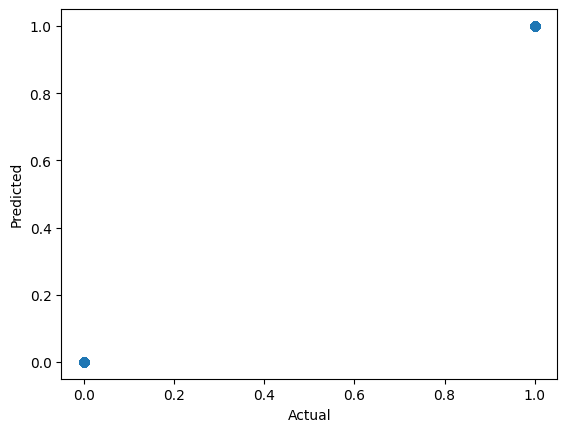

In [26]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

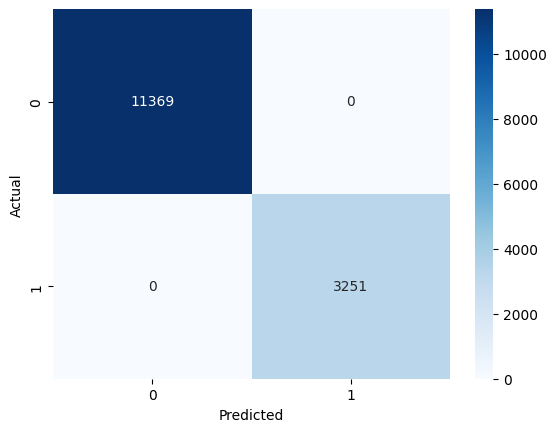

In [27]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

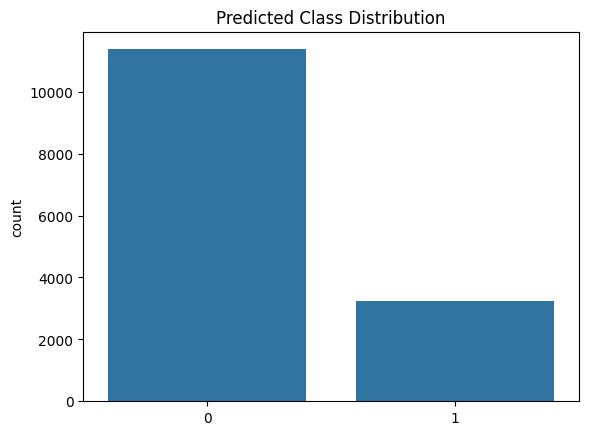

In [28]:
sns.countplot(x=y_pred)
plt.title("Predicted Class Distribution")
plt.show()